In [84]:
import warnings
warnings.filterwarnings("ignore", message="numpy.dtype size changed")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import glob
import random
import tempfile
import gzip
import pylhe
import math
from scipy.optimize import curve_fit
from mpl_toolkits.mplot3d import Axes3D
from auxPlots import  xSecTest, getInfoSMS
from aux import getLHEevents, getDistributions, getInfo, getInfoSummary
from matplotlib.ticker import FixedLocator

pd.option_context('display.max_columns', -1)

pd.options.mode.chained_assignment = None #Disable copy warnings
# plt.style.use('fivethirtyeight') #Set style
# mpl.rcParams.update({'figure.figsize' : (15,10)})  #Set general plotting options
plt.rcParams['figure.max_open_warning'] = 50
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica"]})

plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'

plt.rcParams.update({"savefig.dpi" : 300}) #Figure resolution


#Define plotting style:
sns.set() #Set style
sns.set_style('ticks',{'font.family':'Times New Roman', 'font.serif':'Times New Roman'})
sns.set_context('paper', font_scale=1.8)
cm = plt.colormaps['RdYlBu']

In [2]:
def selectColor(model, process):
    if model == 'VLF EFT':
        return sns.color_palette('Paired')[0]
    elif model == '1-loop VLF':
        return sns.color_palette('Paired')[1]
    elif model == 'Scalar EFT':
        return sns.color_palette('Paired')[2]
    elif model == 'SM':
        return sns.color_palette('Paired')[9]
    else:
        return sns.color_palette('Paired')[3]

In [3]:
def selectColor1(model, process):
    if model == '1-loop VLF':
        if process == r'$q q \to t \bar{t}$':
            return sns.color_palette("RdPu", n_colors=4 + 3)[3]
        else:
            return sns.color_palette("RdPu", n_colors=4 + 3)[4]
    elif model == '1-loop Scalar':
        if process == r'$q q \to t \bar{t}$':
            return sns.color_palette("GnBu", n_colors=4 + 3)[3]
        else:
            return sns.color_palette("GnBu", n_colors=4 + 3)[5]
    else:
        return sns.color_palette('Paired')[3]

# Combining the process to obtain $pp \to t\bar{t}$

In [62]:
files = list(glob.glob('/home/vinicius/EFT_ToyModel/processFolders/Distributions/bias/*/*/bias_article/*.npz'))
data = []
for f in files:
    aux = np.load(f, allow_pickle = True)
    data.append(aux)
print(data)    
data = sorted(data, key=lambda d: (d['mass_params'][0], d['mass_params'][1]))

[NpzFile '/home/vinicius/EFT_ToyModel/processFolders/Distributions/bias/UV_BSM/gg2ttbar_gs4_ydm2/bias_article/mPsiT_1000_mSDM_900.npz' with keys: mTT, pT1, pT2, deltaPhi, weights..., NpzFile '/home/vinicius/EFT_ToyModel/processFolders/Distributions/bias/UV_BSM/qq2ttbar_gs4_ydm2/bias_article/mPsiT_1000_mSDM_900_yDM_1.npz' with keys: mTT, pT1, pT2, deltaPhi, weights..., NpzFile '/home/vinicius/EFT_ToyModel/processFolders/Distributions/bias/SMS_1_loop/gg2ttbar_gs4_ydm2/bias_article/mPsiT_1000_mSDM_900.npz' with keys: mTT, pT1, pT2, deltaPhi, weights..., NpzFile '/home/vinicius/EFT_ToyModel/processFolders/Distributions/bias/SMS_1_loop/qq2ttbar_gs4_ydm2/bias_article/mPsiT_1000_mSDM_900.npz' with keys: mTT, pT1, pT2, deltaPhi, weights...]


In [63]:
#Reading files with bias
sm_files = list(glob.glob('/home/vinicius/EFT_ToyModel/processFolders/Distributions/bias/sm/pp2ttbar_gs4/*.npz'))
data_sm_exp = []
#Loading the distributions
for f in  sm_files:
    aux = np.load(f, allow_pickle = True)
    data_sm_exp.append(aux)
        


data_sm_exp = sorted(data_sm_exp, key=lambda d: d['mass_params'][0])

In [64]:
data_NLO = []
for d in data:
    if '1-loop VLF' in d['model'] or '1-loop Scalar' in d['model']:
        data_NLO.append(d)

data_NLO = sorted(data_NLO, key=lambda d: (d['mass_params'][0], d['mass_params'][1]))

### First negative interference in Scalar 

In [65]:
def get_color_by_mass(model, mass):
    mPsiT, mSDM = mass
    
    # --- COLORS FOR VECTOR-LIKE FERMION (VLF) ---
    # Using a progression from bright blue -> dark blue -> purple
    if '1-loop VLF' in model:
        if mPsiT == 500.0 and mSDM == 375.0:
            return 'deepskyblue'   # Bright, distinct blue
        elif mPsiT == 500.0 and mSDM == 475.0:
            return 'dodgerblue'         # Standard pure blue
        elif mPsiT == 600.0 and mSDM == 475.0:
            return 'blue'         # Very dark blue
        elif mPsiT == 1500.0 and mSDM == 1425.0:
            return 'navy'   # Purple-ish blue to separate high mass
        else:
            return 'cornflowerblue' # Fallback

    # --- COLORS FOR SCALAR ---
    # Using a progression from bright green -> dark green -> teal
    elif '1-loop Scalar' in model:
        if mPsiT == 500.0 and mSDM == 375.0:
            return 'chartreuse'    # Bright, distinct green
        elif mPsiT == 500.0 and mSDM == 475.0:
            return 'limegreen'  # Standard deep green
        elif mPsiT == 600.0 and mSDM == 475.0:
            return 'forestgreen'    # Very dark green
        elif mPsiT == 1500.0 and mSDM == 1425.0:
            return 'darkgreen'         # Blue-green to separate high mass
        else:
            return 'mediumseagreen' # Fallback
    elif 'Z prime' in model:
        return sns.color_palette('Paired')[5]

    # --- DEFAULT ---
    else:
        return 'black'

In [66]:

files = list(glob.glob('/home/vinicius/EFT_ToyModel/processFolders/Distributions/bias/z_prime/pp2ttbar_dmv4/bias_2000_20/*.npz'))
print(files)
#files = list(glob.glob('/home/vinicius/EFT_ToyModel/test/Distributions/*/*/*.npz'))
data_Z = []
#data_sm = []
#Loading the distributions
for f in files:
    aux = np.load(f, allow_pickle = True)
    data_Z.append(aux)

data_Z = sorted(data_Z, key=lambda d: d['mZp'])

['/home/vinicius/EFT_ToyModel/processFolders/Distributions/bias/z_prime/pp2ttbar_dmv4/bias_2000_20/mZp_2000.npz']


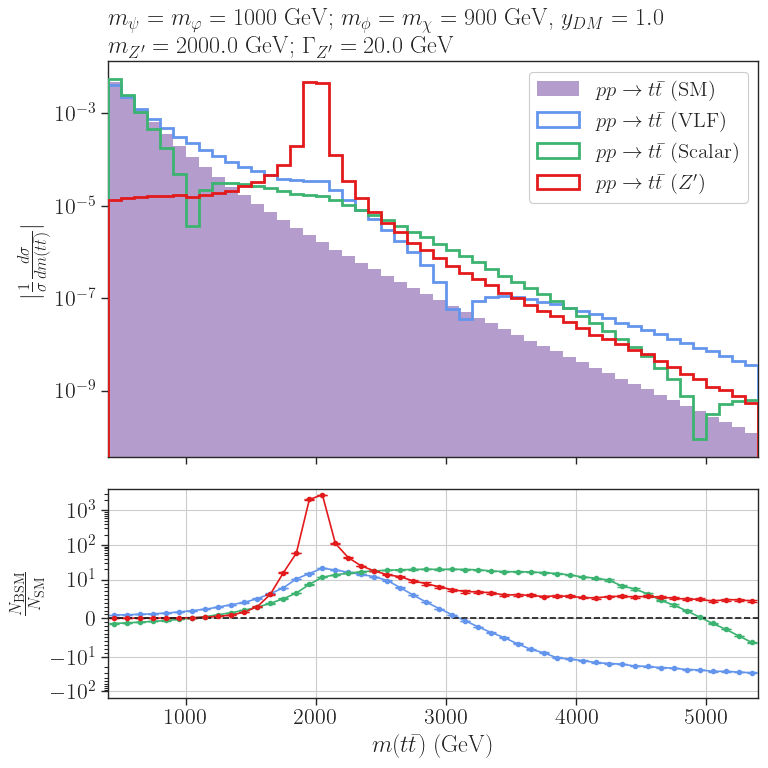

In [177]:
# Loop over the masses configurations. Each mass configuration has 4 items (2 models x 2 processes: qq, gg)
for i in range(0, len(data_NLO), 4):
    selected = data_NLO[i : i+4]

    # BSM masses and couplings
    mPsiT, mSDM = selected[0]['mass_params']
    yDM = selected[0]['ydm']
    
    # --- Setup and Binning ---
    fig, axarr = plt.subplots(2, sharex=True, gridspec_kw={'height_ratios': [1.9, 1]}, figsize=(8, 8))
    plt.subplots_adjust(left=0.12, bottom=0.12, right=0.97, top=None, wspace=None, hspace=0.1)

    if mPsiT < 600:
        bins = np.arange(400., 3000., 50.)
    elif mPsiT < 1000:
        bins = np.arange(500., 4000., 75.)
    else:
        bins = np.arange(400., 5500., 100.)
        
    x = (bins[:-1] + bins[1:]) / 2.0  
    bin_widths = np.diff(bins)

    ##############
    #  Main Plot #
    ##############
    
    pmodels = []
    labels_sm = []
    bsm_hists, bsm_errs, bsm_labels, bsm_colors = [], [], [], []

    # Plotting the SM 
    h_sm_total = np.zeros(len(bins)-1)
    hErr_sm_total_sq = np.zeros(len(bins)-1)
    
    for d in data_sm_exp:
        h, _ = np.histogram(d['mTT'], bins=bins, weights=d['weights'])
        hErr_sq, _ = np.histogram(d['mTT'], bins=bins, weights=np.array(d['weights'])**2)
        h_sm_total += h
        hErr_sm_total_sq += hErr_sq
    
    process = r'$p p \to t \bar{t}$'
    model = 'SM'
    pmodels.append(r'%s (%s)' % (process, model))
    label_sm = pmodels[-1]
    labels_sm.append(label_sm)
        
    integral_sm = np.sum(h_sm_total)
    h_sm = h_sm_total / (integral_sm * bin_widths) if integral_sm > 0 else h_sm_total
    hErr_sm = np.sqrt(hErr_sm_total_sq) / (integral_sm * bin_widths) if integral_sm > 0 else np.sqrt(hErr_sm_total_sq)
    
    axarr[0].hist(bins[:-1], weights=np.abs(h_sm), label=label_sm, bins=bins, density = True,
                  color=sns.color_palette('Paired')[9], alpha=0.5, histtype='step', 
                  linewidth=0, fill=True, zorder=0)

    # Plotting the NLO BSM Data (Summing qq + gg for each model)
    for j in range(0, len(selected), 2):
        d = selected[j]
        d_next = selected[j+1]
        
        process = r'$p p \to t \bar{t}$'
        model = d['model']
        model_raw = d['model']
        model_name = str(np.atleast_1d(model_raw)[0])
        display_name = model_name.replace('1-loop ', '')
        pmodels.append(r'%s (%s)' % (process, display_name))
        label = pmodels[-1]
        
        color = get_color_by_mass(model, (mPsiT, mSDM))
        
        h1, _ = np.histogram(d['mTT'], bins=bins, weights=d['weights'])
        hErr1_sq, _ = np.histogram(d['mTT'], bins=bins, weights=np.array(d['weights'])**2)
        
        h2, _ = np.histogram(d_next['mTT'], bins=bins, weights=d_next['weights'])
        hErr2_sq, _ = np.histogram(d_next['mTT'], bins=bins, weights=np.array(d_next['weights'])**2)
        
        h_bsm_total = h1 + h2
        hErr_bsm_total_sq = hErr1_sq + hErr2_sq
        
        integral_bsm = np.sum(h_bsm_total)
        h_bsm = h_bsm_total / (integral_bsm * bin_widths) if integral_bsm > 0 else h_bsm_total
        hErr_bsm = np.sqrt(hErr_bsm_total_sq) / (integral_bsm * bin_widths) if integral_bsm > 0 else np.sqrt(hErr_bsm_total_sq)

        bsm_hists.append(h_bsm)
        bsm_errs.append(hErr_bsm)
        bsm_labels.append(label)
        bsm_colors.append(color)

        axarr[0].hist(bins[:-1], weights=np.abs(h_bsm), label=label, bins=bins,
                      color=color, alpha=1.0, histtype='step', density = True,
                      linewidth=2, fill=False, zorder=3)
        #axarr[0].errorbar(x, np.abs(h_bsm), yerr=hErr_bsm, color=color, 
         #                 fmt='none', capsize=3, capthick=1.2, barsabove=True, alpha=1.0)

   
    h_z_total = np.zeros(len(bins)-1)
    hErr_z_total_sq = np.zeros(len(bins)-1)
    model_z = ""
    
    for d in data_Z:
        h, _ = np.histogram(d['mTT'], bins=bins, weights=d['weights'])
        hErr_sq, _ = np.histogram(d['mTT'], bins=bins, weights=np.array(d['weights'])**2)
        h_z_total += h
        hErr_z_total_sq += hErr_sq
        model_z = d['model']
        
    if len(data_Z) > 0:
        process = r'$p p \to t \bar{t}$'
        pmodels.append(r'%s (%s)' % (process, r'$Z^\prime$'))
        label_z = pmodels[-1]
        
        color_z = get_color_by_mass(model_z, (mPsiT, mSDM)) 
        
        integral_z = np.sum(h_z_total)
        h_z = h_z_total / (integral_z * bin_widths) if integral_z > 0 else h_z_total
        hErr_z = np.sqrt(hErr_z_total_sq) / (integral_z * bin_widths) if integral_z > 0 else np.sqrt(hErr_z_total_sq)
        
        bsm_hists.append(h_z)
        bsm_errs.append(hErr_z)
        bsm_labels.append(label_z)
        bsm_colors.append(color_z)
        
        axarr[0].hist(bins[:-1], weights=np.abs(h_z), label=label_z, bins=bins,
                      color=color_z, alpha=1.0, histtype='step', density = True,
                      linewidth=2, fill=False, zorder=3)
        #axarr[0].errorbar(x, np.abs(h_z), yerr=hErr_z, color=color_z, 
                         # fmt='none', capsize=3, capthick=1.2, barsabove=True, alpha=1.0)


    ############
    #  SUBPLOT #
    ############
    with np.errstate(divide='ignore', invalid='ignore'):
        # Calculate the raw ratio first to properly calculate the relative error
        raw_ratio = np.nan_to_num(np.array(bsm_hists) / h_sm)
        
        ratio = raw_ratio 
        
        # Propagate the errors for the ratio 
        err_bsm_rel = np.nan_to_num(np.array(bsm_errs) / np.array(bsm_hists))
        err_sm_rel = np.nan_to_num(hErr_sm / h_sm)
        
        ratio_err = np.abs(raw_ratio) * np.sqrt(err_bsm_rel**2 + err_sm_rel**2)


    for k, r in enumerate(ratio):
        # Using errorbar for the ratio points to show the propagated MC uncertainty
        axarr[1].errorbar(x, r, yerr=ratio_err[k], color=bsm_colors[k], fmt='o', ms=3, capsize=3.5, label=bsm_labels[k])
        axarr[1].plot(x, r, color=bsm_colors[k]) # Add a line connecting points


    #################
    #  Plot configs #
    #################
    
    # Safely extract Z' properties
    mZp = data_Z[0].get('mZp', 0.0) if len(data_Z) > 0 else 0.0
    wZp = data_Z[0].get('wZp', 0.0) if len(data_Z) > 0 else 0.0

    # Upper plot
    axarr[0].legend(framealpha=1.0, ncol=1, loc='upper right', fontsize=15)
    axarr[0].set_title(
        (r'$m_{\psi} = m_{\varphi} = %1.0f$ GeV; $m_{\phi} = m_\chi = %1.0f$ GeV, $y_{DM} = %1.1f$' + '\n' +
         r'$m_{Z^\prime} = %1.1f$ GeV; $\Gamma_{Z^\prime} = %1.1f$ GeV') % 
        (mPsiT, mSDM, yDM, mZp, 20.0), 
        loc='left'
    )
    axarr[0].set_yscale('log')
    axarr[0].set_ylabel(r'$|\frac{1}{\sigma}\frac{d \sigma}{d m(t\bar{t})}|$')
    axarr[0].set_xlim(bins.min(), bins.max())


    # Bottom plot
    axarr[1].axhline(y=0, color='k', linestyle='--') # Baseline is now at 0
    axarr[1].set_ylabel(r'$\frac{N_{\mathrm{BSM}}}{ N_{\mathrm{SM}}}$') 
    axarr[1].set_xlabel(r'$m(t\bar{t})$ (GeV)')
    axarr[1].grid(True)
    axarr[1].set_yscale('symlog', linthresh = 10.0)
    axarr[1].set_ylim([-150.0, 4000.0])
    
    
    minor_tick_locations = np.concatenate((np.arange(-100.0, 0.0, 10.0 ), np.arange(-10.0, 1.0, 1.0 ), np.arange(0.0,11.0,1.0 ),
                                          np.arange(10.0, 100.0, 10.0), np.arange(100.0, 1100.0, 100.0),
                                          np.arange(1000.0, 4000.0, 1000.0))) # Add more as needed for your data range
    axarr[1].yaxis.set_minor_locator(FixedLocator(minor_tick_locations))

    plt.tight_layout()
    #filename = f"mtt_pp_mPsiT_{int(mPsiT)}_mSDM_{int(mSDM)}_ratio.png"
    plt.savefig('Dists_comparison_interference.png')
    plt.show()

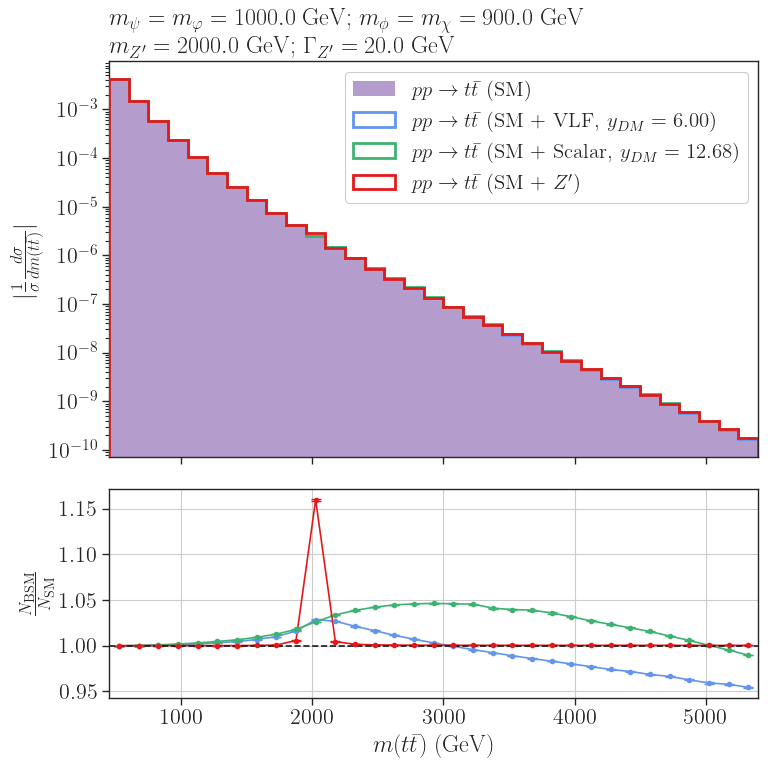

In [178]:


# Loop over the masses configurations. Each mass configuration has 4 items (2 models x 2 processes: qq, gg)
for i in range(0, len(data_NLO), 4):
    selected = data_NLO[i : i+4]

    # BSM masses and couplings
    mPsiT, mSDM = selected[0]['mass_params']
    yDM = selected[0]['ydm']
    
    # --- Setup and Binning ---
    fig, axarr = plt.subplots(2, sharex=True, gridspec_kw={'height_ratios': [1.9, 1]}, figsize=(8, 8))
    plt.subplots_adjust(left=0.12, bottom=0.12, right=0.97, top=None, wspace=None, hspace=0.1)

    if mPsiT < 600:
        bins = np.arange(400., 3000., 50.)
    elif mPsiT < 1000:
        bins = np.arange(500., 4000., 75.)
    else:
        bins = np.arange(450., 5500., 150.)
        
    x = (bins[:-1] + bins[1:]) / 2.0  
    bin_widths = np.diff(bins)

    ##############
    #  Main Plot #
    ##############
    
    pmodels = []
    labels_sm = []
    
    
    bsm_ratios, bsm_ratio_errs, bsm_labels, bsm_colors = [], [], [], []

    # ==========================================
    # 1 Plotting and Storing the SM (Raw Data)
    # ==========================================
    h_sm_raw = np.zeros(len(bins)-1)
    hErr_sm_raw_sq = np.zeros(len(bins)-1)
    
    for d in data_sm_exp:
        h, _ = np.histogram(d['mTT'], bins=bins, weights=d['weights'])
        hErr_sq, _ = np.histogram(d['mTT'], bins=bins, weights=np.array(d['weights'])**2)
        h_sm_raw += h
        hErr_sm_raw_sq += hErr_sq
    
    process = r'$p p \to t \bar{t}$'
    model = 'SM'
    pmodels.append(r'%s (%s)' % (process, model))
    label_sm = pmodels[-1]
    labels_sm.append(label_sm)
        
    # Density Normalization for SM
    integral_sm = np.sum(h_sm_raw)
    h_sm = h_sm_raw / (integral_sm * bin_widths) if integral_sm > 0 else h_sm_raw
    hErr_sm = np.sqrt(hErr_sm_raw_sq) / (integral_sm * bin_widths) if integral_sm > 0 else np.sqrt(hErr_sm_raw_sq)
    
    axarr[0].hist(bins[:-1], weights=np.abs(h_sm), label=label_sm, bins=bins, density=True,
                  color=sns.color_palette('Paired')[9], alpha=0.5, histtype='step', 
                  linewidth=0, fill=True, zorder=0)

    # ==========================================
    #  Plotting the NLO BSM Data (SM + BSM)
    # ==========================================
    y_DM = {'1-loop VLF': 6.0, '1-loop Scalar': 1.268000e+01}
    for j in range(0, len(selected), 2):
        d = selected[j]
        d_next = selected[j+1]
        
        process = r'$p p \to t \bar{t}$'
        
        model_raw = d['model']
        model_name = str(np.atleast_1d(model_raw)[0])
        
        val_y_dm = y_DM.get(model_name, 1.0)
        

        display_name = model_name.replace('1-loop ', '')
        pmodels.append(r'%s (SM + %s, $y_{DM} = %.2f$)' % (process, display_name, val_y_dm))
        label = pmodels[-1]
        
        color = get_color_by_mass(model_name, (mPsiT, mSDM))
        
        h1, _ = np.histogram(d['mTT'], bins=bins, weights=d['weights'])
        hErr1_sq, _ = np.histogram(d['mTT'], bins=bins, weights=np.array(d['weights'])**2)
        
        h2, _ = np.histogram(d_next['mTT'], bins=bins, weights=d_next['weights'])
        hErr2_sq, _ = np.histogram(d_next['mTT'], bins=bins, weights=np.array(d_next['weights'])**2)
        
        # Summing BSM and SM Raw Data
        scale_weight = y_DM.get(model_name, 1.0)**2 
        
        h_bsm_raw = (h1 + h2) * scale_weight
        hErr_bsm_raw_sq = (hErr1_sq + hErr2_sq) * (scale_weight**2)
        
        h_combined_raw = h_bsm_raw + h_sm_raw
        hErr_combined_raw_sq = hErr_bsm_raw_sq + hErr_sm_raw_sq
        
        # Density Normalization for combined data
        integral_combined = np.sum(h_combined_raw)
        h_combined = h_combined_raw / (integral_combined * bin_widths) if integral_combined > 0 else h_combined_raw
        hErr_combined = np.sqrt(hErr_combined_raw_sq) / (integral_combined * bin_widths) if integral_combined > 0 else np.sqrt(hErr_combined_raw_sq)

        axarr[0].hist(bins[:-1], weights=np.abs(h_combined), label=label, bins=bins,
                      color=color, alpha=1.0, histtype='step', density=True,
                      linewidth=2, fill=False, zorder=3)

        # --- Propagating error ---
        with np.errstate(divide='ignore', invalid='ignore'):
            ratio_raw = h_combined_raw / h_sm_raw
            
            err_bsm_raw = np.sqrt(hErr_bsm_raw_sq)
            err_sm_raw = np.sqrt(hErr_sm_raw_sq)
            
            ratio_raw_err = (1.0 / h_sm_raw) * np.sqrt(err_bsm_raw**2 + (h_bsm_raw / h_sm_raw)**2 * err_sm_raw**2)
            
            scale_factor = integral_sm / integral_combined if integral_combined > 0 else 1.0
            
            ratio = ratio_raw * scale_factor
            ratio_err = ratio_raw_err * scale_factor
            
            zero_mask = (h_sm_raw == 0)
            ratio[zero_mask] = np.nan
            ratio_err[zero_mask] = np.nan
            
        bsm_ratios.append(ratio)
        bsm_ratio_errs.append(ratio_err)
        bsm_labels.append(label)
        bsm_colors.append(color)

    # ==========================================
    # Plotting the Z' Data (SM + Z')
    # ==========================================
    h_z_raw = np.zeros(len(bins)-1)
    hErr_z_raw_sq = np.zeros(len(bins)-1)
    model_z = ""
    
    for d in data_Z:
        h, _ = np.histogram(d['mTT'], bins=bins, weights=d['weights'])
        hErr_sq, _ = np.histogram(d['mTT'], bins=bins, weights=np.array(d['weights'])**2)
        h_z_raw += h
        hErr_z_raw_sq += hErr_sq
        m_arr = d['model']
        model_z = str(np.atleast_1d(m_arr)[0])
        
    if len(data_Z) > 0:
        process = r'$p p \to t \bar{t}$'
        pmodels.append(r'%s (SM + %s)' % (process, r'$Z^\prime$'))
        label_z = pmodels[-1]
        
        color_z = get_color_by_mass(model_z, (mPsiT, mSDM)) 
        
        h_combined_z_raw = h_z_raw + h_sm_raw
        hErr_combined_z_raw_sq = hErr_z_raw_sq + hErr_sm_raw_sq
        
        integral_combined_z = np.sum(h_combined_z_raw)
        h_combined_z = h_combined_z_raw / (integral_combined_z * bin_widths) if integral_combined_z > 0 else h_combined_z_raw
        hErr_combined_z = np.sqrt(hErr_combined_z_raw_sq) / (integral_combined_z * bin_widths) if integral_combined_z > 0 else np.sqrt(hErr_combined_z_raw_sq)
        
        axarr[0].hist(bins[:-1], weights=np.abs(h_combined_z), label=label_z, bins=bins,
                      color=color_z, alpha=1.0, histtype='step', density=True,
                      linewidth=2, fill=False, zorder=3)
                      
        # --- Propagação Correta de Erro para Z' ---
        with np.errstate(divide='ignore', invalid='ignore'):
            ratio_raw = h_combined_z_raw / h_sm_raw
            err_z_raw = np.sqrt(hErr_z_raw_sq)
            err_sm_raw = np.sqrt(hErr_sm_raw_sq)
            
            ratio_raw_err = (1.0 / h_sm_raw) * np.sqrt(err_z_raw**2 + (h_z_raw / h_sm_raw)**2 * err_sm_raw**2)
            
            scale_factor = integral_sm / integral_combined_z if integral_combined_z > 0 else 1.0
            
            ratio = ratio_raw * scale_factor
            ratio_err = ratio_raw_err * scale_factor
            
            zero_mask = (h_sm_raw == 0)
            ratio[zero_mask] = np.nan
            ratio_err[zero_mask] = np.nan
            
        bsm_ratios.append(ratio)
        bsm_ratio_errs.append(ratio_err)
        bsm_labels.append(label_z)
        bsm_colors.append(color_z)

    ############
    #  SUBPLOT #
    ############
    
    for k, r in enumerate(bsm_ratios):
        axarr[1].errorbar(x, r, yerr=bsm_ratio_errs[k], color=bsm_colors[k], fmt='o', ms=3, capsize=3.5, label=bsm_labels[k])
        axarr[1].plot(x, r, color=bsm_colors[k]) 


    #################
    #  Plot configs #
    #################
    
    mZp = data_Z[0].get('mZp', 0.0) if len(data_Z) > 0 else 0.0
    wZp = data_Z[0].get('wZp', 0.0) if len(data_Z) > 0 else 0.0

    # Upper plot
    axarr[0].legend(framealpha=1.0, ncol=1, loc='upper right', fontsize=15)
    axarr[0].set_title(
        (r'$m_{\psi} = m_{\varphi} = %1.1f$ GeV; $m_{\phi} = m_\chi = %1.1f$ GeV' + '\n' +
         r'$m_{Z^\prime} = %1.1f$ GeV; $\Gamma_{Z^\prime} = %1.1f$ GeV') % 
        (mPsiT, mSDM, mZp, 20.0), 
        loc='left'
    )
    axarr[0].set_yscale('log')
    axarr[0].set_ylabel(r'$|\frac{1}{\sigma}\frac{d \sigma}{d m(t\bar{t})}|$')
    axarr[0].set_xlim(bins.min(), bins.max())


    # Bottom plot
    axarr[1].axhline(y=1.0, color='k', linestyle='--') 
    axarr[1].set_ylabel(r'$\frac{N_{\mathrm{BSM}}}{ N_{\mathrm{SM}}}$') 
    axarr[1].set_xlabel(r'$m(t\bar{t})$ (GeV)')
    axarr[1].grid(True)
    axarr[1].set_yticks(np.arange(0.95,1.2, 0.05))
    
    plt.tight_layout()
    plt.savefig('Dists_comparison.png')
    plt.show()